In [89]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import ND_parser

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version

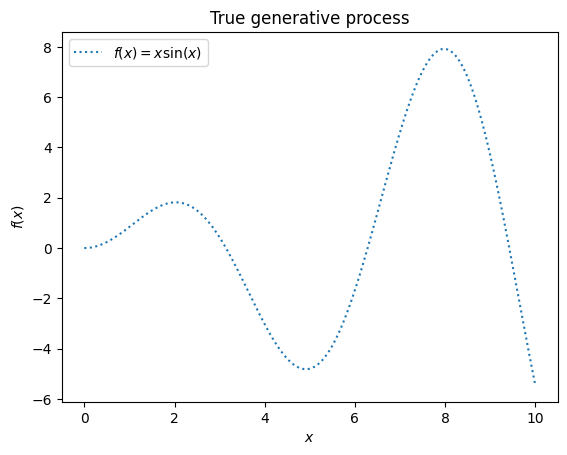

In [13]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))

plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [14]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]

In [15]:
kernel = 1 * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=9)
gaussian_process.fit(X_train, y_train)
gaussian_process.kernel_

5.02**2 * RBF(length_scale=1.43)

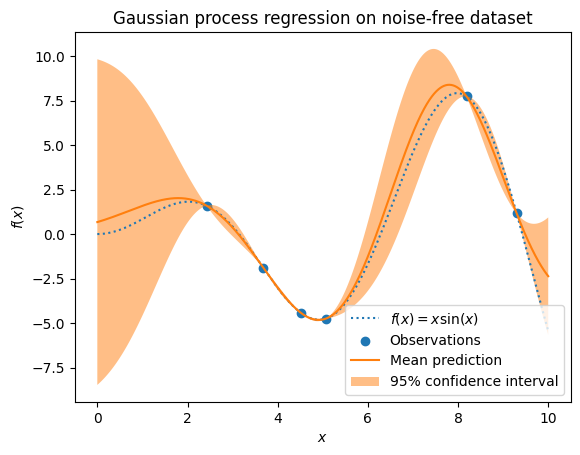

In [16]:
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

In [17]:
noise_std = 0.75
y_train_noisy = y_train + rng.normal(loc=0.0, scale=noise_std, size=y_train.shape)

In [18]:
gaussian_process = GaussianProcessRegressor(
    kernel=kernel, alpha=noise_std**2, n_restarts_optimizer=9
)
gaussian_process.fit(X_train, y_train_noisy)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)

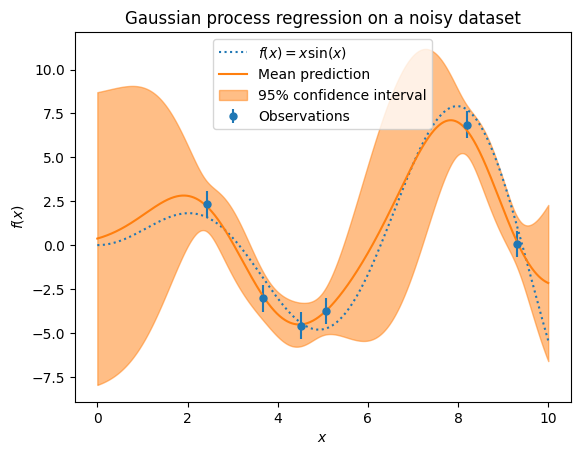

In [19]:
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.errorbar(
    X_train,
    y_train_noisy,
    noise_std,
    linestyle="None",
    color="tab:blue",
    marker=".",
    markersize=10,
    label="Observations",
)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    color="tab:orange",
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on a noisy dataset")

In [82]:
diabetes = datasets.load_diabetes()
X, y = diabetes.data, diabetes.target

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=13
)

params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_split": 5,
    "learning_rate": 0.01,
    "loss": "squared_error",
}

In [85]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))

The mean squared error (MSE) on test set: 3021.2750


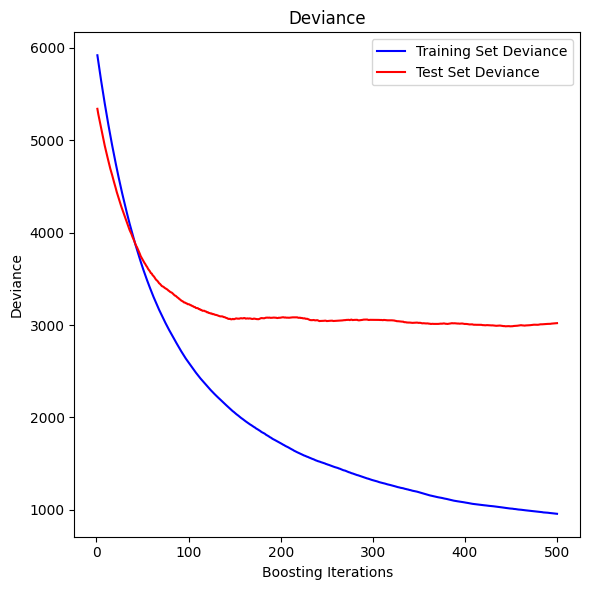

In [86]:
test_score = np.zeros((params["n_estimators"],), dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(
    np.arange(params["n_estimators"]) + 1,
    reg.train_score_,
    "b-",
    label="Training Set Deviance",
)
plt.plot(
    np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance"
)
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()

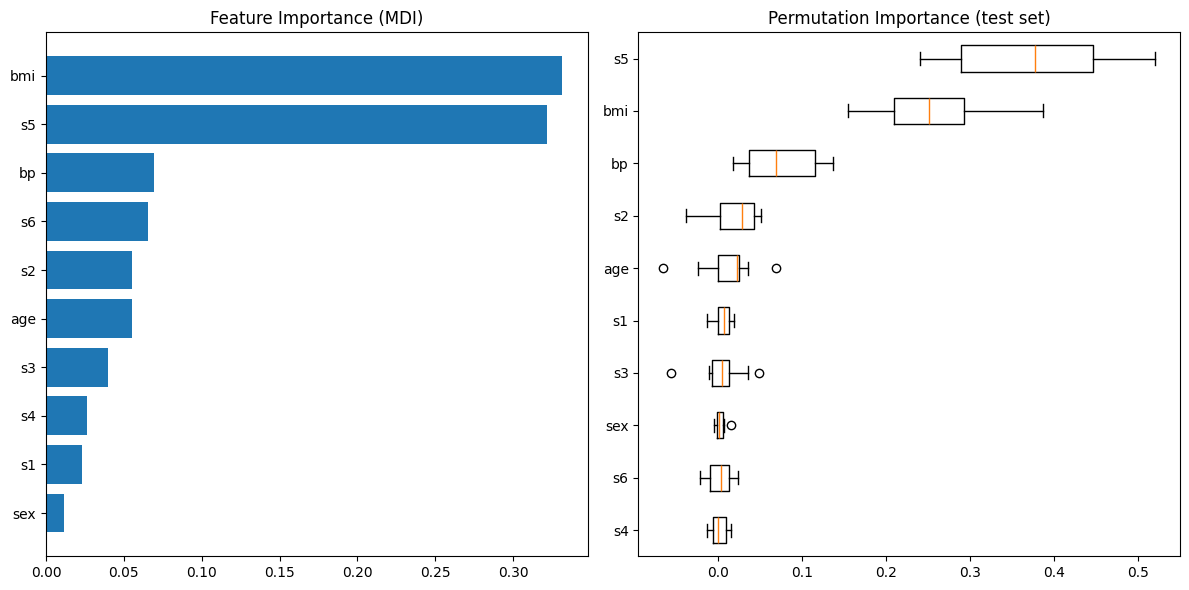

In [87]:
feature_importance = reg.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(diabetes.feature_names)[sorted_idx])
plt.title("Feature Importance (MDI)")

result = permutation_importance(
    reg, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)

tick_labels_parameter_name = (
    "tick_labels"
    if parse_version(matplotlib.__version__) >= parse_version("3.9")
    else "labels"
)
tick_labels_dict = {
    tick_labels_parameter_name: np.array(diabetes.feature_names)[sorted_idx]
}
plt.boxplot(result.importances[sorted_idx].T, vert=False, **tick_labels_dict)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

In [40]:
cl_35 = ND_parser.find_most_recent_exfor_data("17-CL-35", "(N,P)", "C:/Users/jakeh/PycharmProjects/ML4ND_py/exfor_master/exforall")
cl_35_endf = ND_parser.read_END_CSV("CL35_MF3_MT103.csv")

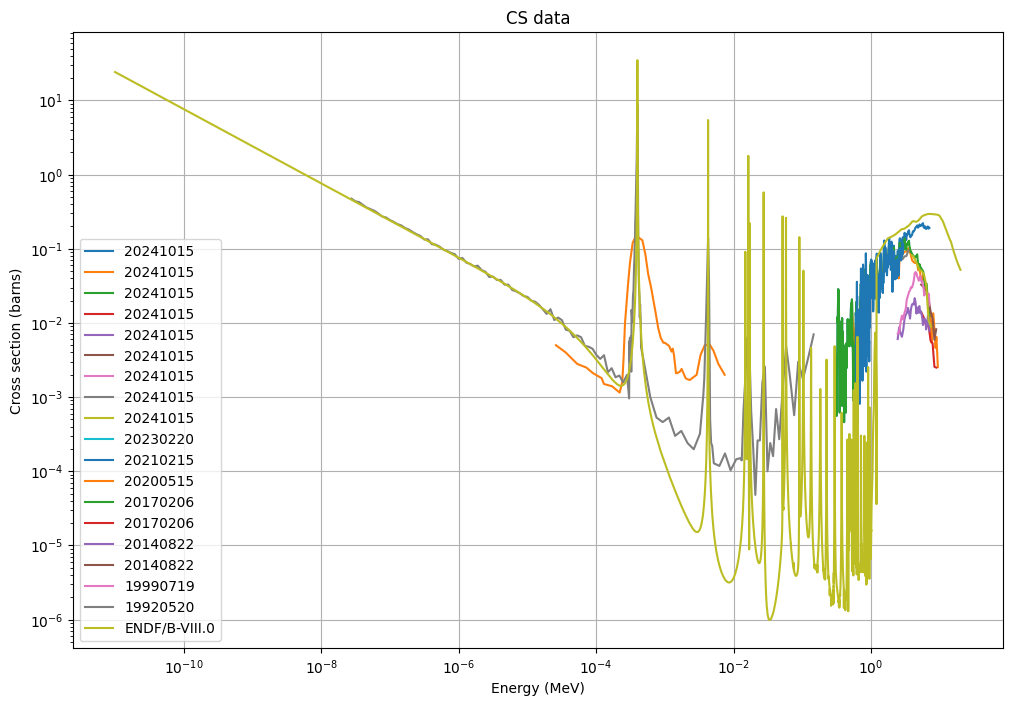

In [43]:
plt.figure(figsize=(12, 8))
plt.title("CS data")
plt.xlabel("Energy (MeV)")
plt.ylabel("Cross section (barns)")
plt.xscale("log")
plt.yscale("log")

for date, path in cl_35:
    file_parsed = ND_parser.parse_exfor_file(path)
    for subentry in file_parsed["subentries"]:
        if subentry["reaction"]:
            if "17-CL-35(N,P)" in subentry["reaction"]:
                if len(subentry["data"]) > 0:
                    df = subentry["data"][0]
                    if "EN (MeV)" in list(df) and "DATA (b)" in list(df):
                        plt.plot(df["EN (MeV)"], df["DATA (b)"], label=date)

plt.plot(cl_35_endf["Incident energy"]*1e-6, cl_35_endf["ENDF/B-VIII.0"], label="ENDF/B-VIII.0")
plt.legend()
plt.grid()
plt.show()

         EN (MeV)  DATA (b)  DATA-ERR (b)
0    2.750000e-08   0.47360       0.00520
1    3.130000e-08   0.43620       0.00470
2    3.560000e-08   0.42500       0.00430
3    4.040000e-08   0.38940       0.00390
4    4.600000e-08   0.35860       0.00360
..            ...       ...           ...
161  7.600000e-02   0.00057       0.00029
162  8.700000e-02   0.00300       0.00200
163  1.020000e-01   0.00174       0.00044
164  1.210000e-01   0.00332       0.00081
165  1.460000e-01   0.00700       0.00140

[166 rows x 3 columns]


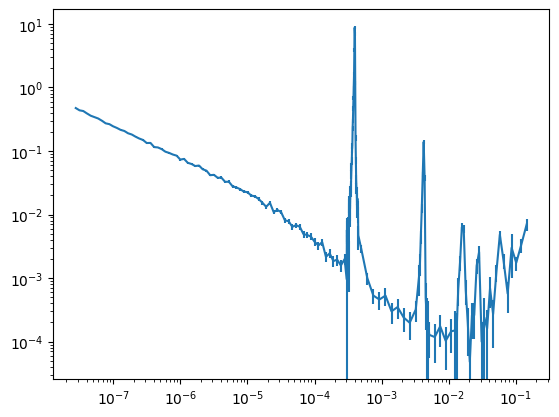

In [54]:
file_parsed = ND_parser.parse_exfor_file(cl_35[-1][1])
training_data = None
for subentry in file_parsed["subentries"]:
    if subentry["reaction"]:
        if "17-CL-35(N,P)" in subentry["reaction"]:
            if len(subentry["data"]) > 0:
                df = subentry["data"][0]
                if "EN (MeV)" in list(df) and "DATA (b)" in list(df):
                    training_data = df
print(training_data)
plt.errorbar(training_data["EN (MeV)"], training_data["DATA (b)"], yerr=training_data["DATA-ERR (b)"])
plt.xscale("log")
plt.yscale("log")

In [55]:
from sklearn.model_selection import train_test_split

df = training_data.sort_values("EN (MeV)")

split_idx = int(0.8 * len(df))

train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]

X_train = train.drop("DATA (b)", axis=1).values
y_train = train["DATA (b)"].values

X_test = test.drop("DATA (b)", axis=1).values
y_test = test["DATA (b)"].values

In [66]:
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

kernel = (
    C(1.0, (1e-8, 1e6)) * RBF(10.0, (1e-4, 1e4)) +
    C(1.0, (1e-8, 1e6)) * RBF(0.01, (1e-8, 1.0)) +
    WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-12, 1e1))
)

from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = X_scaler.fit_transform(X_train)
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
gp.fit(X_train, y_train)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=10) + 1**2 * RBF(length_scale=0.01) + WhiteKernel(noise_level=0.0001),
                         n_restarts_optimizer=20)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

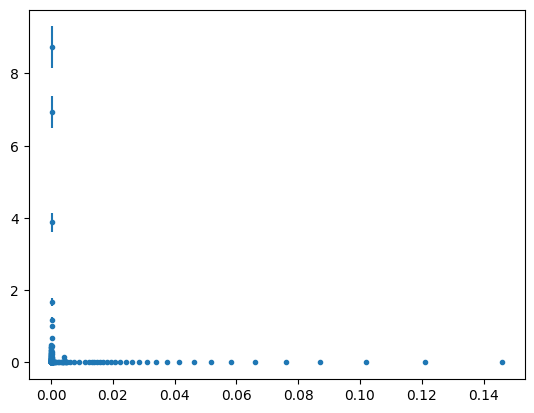

In [75]:
X = training_data.drop("DATA (b)", axis=1)
y = training_data["DATA (b)"].values
yerr = training_data["DATA-ERR (b)"].values

mean_prediction, std_prediction = gp.predict(X.values, return_std=True)

plt.errorbar(X["EN (MeV)"], y, yerr=yerr, fmt=".")
plt.scatter(X_train["EN (MeV)"], y_train, label="Observations")
plt.plot(X["EN (MeV)"], mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on exfor dataset")